# Project 3 | Build and Visualize a Perceptron

## Project Description

**Objective**: Implement the complete Perceptron learning algorithm from scratch using NumPy.

Your implementation should:

- Initialize weights and bias.
- Train using the Perceptron Learning Rule.
- Iterate over a linearly separable binary classification dataset.
- Track the number of misclassifications per epoch.
- Plot the learned decision boundary (for a 2D dataset).
- Experiment with different learning rates and observe how training changes.

The purpose of this project is to see learning happen visually: the decision boundary moving as the model corrects its mistakes.

## My Solution

In [117]:
from pprint import pprint

import numpy as np
import pandas as pd

from matplotlib.figure import Figure
from IPython.display import display
import seaborn as sns

from sklearn.datasets import load_iris

In [118]:
dataset = load_iris(as_frame=True).frame
dataset = dataset[dataset['target'] < 2]
dataset = dataset.drop(['sepal width (cm)', 'petal width (cm)'], axis=1)
X = dataset.drop('target', axis=1)
y = dataset['target']

In [119]:
dataset

,sepal length (cm),petal length (cm),target
0,5.1,1.4,0
1,4.9,1.4,0
2,4.7,1.3,0
3,4.6,1.5,0
4,5.0,1.4,0
...,...,...,...
95,5.7,4.2,1
96,5.7,4.2,1
97,6.2,4.3,1
98,5.1,3.0,1


In [120]:
x1 = 'sepal length (cm)'
x2 = 'petal length (cm)'

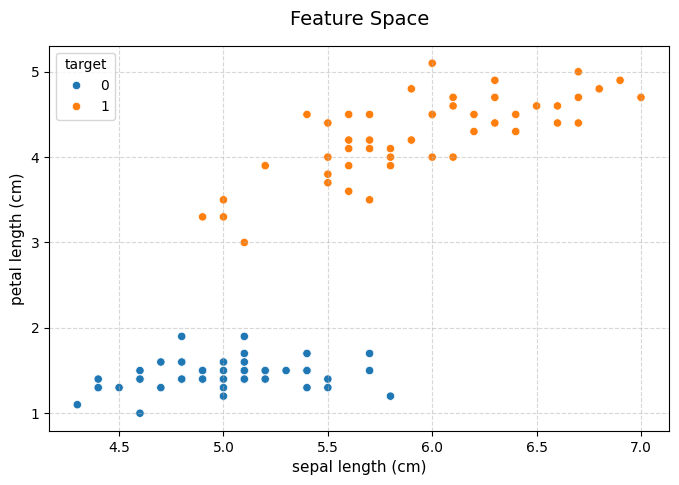

In [121]:
figureFeatureSpace = Figure(figsize=(8, 5))

axesFeatureSpace = figureFeatureSpace.add_subplot(1, 1, 1)

sns.scatterplot(data=dataset, x=x1, y=x2, hue=y, ax=axesFeatureSpace, color="#2b5c8f", alpha=1)

axesFeatureSpace.set_title("Feature Space", fontsize=14, pad=15)
axesFeatureSpace.set_xlabel(x1, fontsize=11)
axesFeatureSpace.set_ylabel(x2, fontsize=11)
axesFeatureSpace.grid(True, linestyle="--", alpha=0.5)

figureFeatureSpace.canvas.draw()
display(figureFeatureSpace)

The dataset is clearly linearly separable. I will train my perceptrons until I get a perfect decision boundary for 10 consecutive epochs.

In [122]:
def get_square_axis_limits_data_focused(x, y, margin=0.1):
    """Calculates symmetric x and y limits with an added margin to create a square

    plot frame covering all data points.

    Parameters:
    -----------
    x : array-like
        Feature values for x-axis.
    y : array-like
        Feature values for y-axis.
    margin : float, default=0.1
        Percentage margin (0.1 = 10%) to pad around the global min and max.

    Returns:
    --------
    min_limit : float
        Lower bound for both set_xlim and set_ylim.
    max_limit : float
        Upper bound for both set_xlim and set_ylim.
    """
    x_arr = np.asarray(x)
    y_arr = np.asarray(y)

    # 1. Find the global min and max across BOTH features
    global_min = min(np.min(x_arr), np.min(y_arr))
    global_max = max(np.max(x_arr), np.max(y_arr))

    # 2. Calculate span and margin padding
    data_span = global_max - global_min
    # Fallback to prevent 0 division if all data points are identical
    padding = data_span * margin if data_span > 0 else 1.0

    # 3. Apply padding
    min_limit = global_min - padding
    max_limit = global_max + padding

    return min_limit, max_limit

In [123]:
def get_square_axis_limits_DB_focused(
    x, y, decision_boundaries, margin=0.1, margin_after_zero=0.2
):
    """Calculates symmetric x and y limits that cover all data points AND ensure all

    decision boundaries cross the zero-lines with extra extension.

    Parameters:
    -----------
    x : array-like
        Feature values for x-axis.
    y : array-like
        Feature values for y-axis.
    decision_boundaries : list of tuples
        List of (w, b) pairs representing each decision boundary.
        w can be a list/array [w1, w2], and b is a scalar float.
    margin : float, default=0.1
        Percentage margin padding applied around the global bounds.
    margin_after_zero : float, default=0.2
        Extra extension past zero-crossings for boundary lines.

    Returns:
    --------
    min_db_limit : float
        Lower bound for both set_xlim and set_ylim.
    max_db_limit : float
        Upper bound for both set_xlim and set_ylim.
    """
    x_arr = np.asarray(x)
    y_arr = np.asarray(y)

    # 1. Start with global min/max from data points + origin (0, 0)
    all_critical_points = [
        np.min(x_arr),
        np.max(x_arr),
        np.min(y_arr),
        np.max(y_arr),
        0.0,  # Ensure origin is always included
    ]

    

    # 2. Collect key intercepts for every decision boundary
    for w, b in decision_boundaries:
        w1, w2 = w[0], w[1]

        if w1 == 0 and w2 == 0:
            continue

        # x1-intercept (where x2 = 0): w1*x1 + b = 0 -> x1 = -b / w1
        if w1 != 0:
            x1_intercept = -b / w1
            all_critical_points.append(x1_intercept)
            # Add extra extension past the intercept
            all_critical_points.append(
                x1_intercept * (1.0 + margin_after_zero)
            )

        # x2-intercept (where x1 = 0): w2*x2 + b = 0 -> x2 = -b / w2
        if w2 != 0:
            x2_intercept = -b / w2
            all_critical_points.append(x2_intercept)
            # Add extra extension past the intercept
            all_critical_points.append(
                x2_intercept * (1.0 + margin_after_zero)
            )

    # 3. Find overall min and max across data + intercepts
    global_min = min(all_critical_points)
    global_max = max(all_critical_points)

    # 4. Apply overall plot margin padding
    data_span = global_max - global_min
    padding = data_span * margin if data_span > 0 else 1.0

    min_db_limit = global_min - padding
    max_db_limit = global_max + padding

    return min_db_limit, max_db_limit

In [126]:
def generate_line_points(
    w, b, x1_range=(-1000, 1000), x2_range=(-1000, 1000), num_points=500
):
    """Generates 2D coordinates for a decision boundary line w1*x1 + w2*x2 + b = 0.

    Returns:
        (x1_coords_in_range, x2_coords_in_range, x1_coords, x2_coords)
    """
    w1, w2 = w[0], w[1]

    # Case 1: Line is undefined
    if w1 == 0 and w2 == 0:
        raise ValueError(
            "Weights w1 and w2 cannot both be zero. Undefined decision boundary."
        )

    # 1. Generate full line coordinates evaluated across x1_range
    if w2 == 0:  # Vertical line (x1 = -b / w1)
        x1_fixed = -b / w1
        x1_coords = np.full(num_points, x1_fixed)
        x2_coords = np.linspace(x2_range[0], x2_range[1], num_points)
    else:  # Standard or horizontal line
        x1_coords = np.linspace(x1_range[0], x1_range[1], num_points)
        x2_coords = (-w1 * x1_coords - b) / w2

    # 2. Filter points strictly inside both x1_range and x2_range
    mask = (
        (x1_coords >= x1_range[0])
        & (x1_coords <= x1_range[1])
        & (x2_coords >= x2_range[0])
        & (x2_coords <= x2_range[1])
    )

    x1_coords_in_range = x1_coords[mask]
    x2_coords_in_range = x2_coords[mask]

    return (
        x1_coords_in_range,
        x2_coords_in_range
    )

In [115]:
class Perceptron:
    def __init__(self, eta):
        self.eta = eta
        self.w = np.array([0, 0])
        self.b = 0

    def activation(self, z):
        return np.where(z>=0, 1, 0)

    def predict(self, X):
        return self.activation(np.dot(X, self.w) + self.b)

    def fit(self, X, y, initial_w = np.array([0, 0]), initial_b = 0, required_number_of_consecutive_perfection = 1, verbose = True):
        self.w = initial_w
        self.b = initial_b
        
        epoch_number = 0
        number_of_consecutive_perfection = 0
        min_limit, max_limit = get_square_axis_limits_data_focused(X, y)

        while number_of_consecutive_perfection < required_number_of_consecutive_perfection:
            # Evaluating Current Decision Boundary
            y_pred = self.predict(X)       
            error = y - y_pred
            pre_epoch_number_of_misclassified_points = (error != 0).sum()
                
    
            # Updating Decision Boundary
            epoch_number += 1
            pre_epoch_w = self.w
            pre_epoch_b = self.b
           
            # Updating Weights and Bias
            self.w = self.w + self.eta * np.dot(X.T, error)
            self.b = self.b + self.eta * np.sum(error)

            # Evaluating Current Decision Boundary
            y_pred = self.predict(X)
            error = y - y_pred
            number_of_misclassified_points = (error != 0).sum()
            perfectly_separated = number_of_misclassified_points == 0

            if perfectly_separated:
                number_of_consecutive_perfection += 1
            else:
                number_of_consecutive_perfection = 0

            if verbose:
                print(f"Epoch Number: {epoch_number}\n")
                print(f"Before this Epoch:\nw = {pre_epoch_w} b = {pre_epoch_b}\nNumber of Misclassified Point(s): {pre_epoch_number_of_misclassified_points}\n\n\n")
                            
                DBs = [
                    (pre_epoch_w, pre_epoch_b), # Before this epoch
                    (pre_epoch_w * np.array([0, 1]) + self.w * np.array([1, 0]), pre_epoch_b), # New w1
                    (self.w, pre_epoch_b), # New w1 and w2
                    (self.w, self.b) # After this Epoch
                ]

                DB_colors = [
                    "#DC143CFF",
                    "#D95F02FF",
                    "#2B5C8FFF",
                    "#2E8B57FF"                    
                ]

                DB_labels = ['Before this Epoch', 'With New w1', 'With New w2', 'After this Epoch']

                min_db_limit, max_db_limit = get_square_axis_limits_DB_focused(X,y, decision_boundaries=DBs)
                
                figureFeatureSpace = Figure(figsize=(16, 5))
                
                axesFeatureSpaceDataPoints = figureFeatureSpace.add_subplot(1, 2, 1)
                axesFeatureSpaceDBs = figureFeatureSpace.add_subplot(1, 2, 2)

                sns.scatterplot(data=dataset, x=x1, y=x2, hue=y, ax=axesFeatureSpaceDataPoints, color="#2b5c8f", alpha=1)
                sns.scatterplot(data=dataset, x=x1, y=x2, hue=y, ax=axesFeatureSpaceDBs, color="#2b5c8f", alpha=1)


                # Plot each line on the Axes objects
                for index, (w, b) in enumerate(DBs):
                    x0, y0 = generate_line_points(w, b, x1_range=(min_limit, max_limit), x2_range=(min_limit, max_limit))
                    sns.lineplot(x=x0, y=y0, label=DB_labels[index], color=DB_colors[index], ax=axesFeatureSpaceDataPoints, linewidth=2)

                    x0, y0 = generate_line_points(w, b, x1_range=(min_db_limit, max_db_limit), x2_range=(min_db_limit, max_db_limit))
                    sns.lineplot(x=x0, y=y0, label=DB_labels[index], color=DB_colors[index], ax=axesFeatureSpaceDBs, linewidth=3.5)

                axesFeatureSpaceDataPoints.set_title("Feature Space in Focus", fontsize=14, pad=15)
                axesFeatureSpaceDataPoints.set_xlabel(x1, fontsize=11)
                axesFeatureSpaceDataPoints.set_ylabel(x2, fontsize=11)
                axesFeatureSpaceDataPoints.grid(True, linestyle="--", alpha=0.5)
                axesFeatureSpaceDataPoints.set_aspect("equal", adjustable="box")
                axesFeatureSpaceDataPoints.set_xlim(min_limit, max_limit)
                axesFeatureSpaceDataPoints.set_ylim(min_limit, max_limit)
                axesFeatureSpaceDataPoints.axhline(0, color="black", linestyle=":", linewidth=1.5, zorder=2)
                axesFeatureSpaceDataPoints.axvline(0, color="black", linestyle=":", linewidth=1.5, zorder=2)

                axesFeatureSpaceDBs.set_title("Decision Boundaries in Focus", fontsize=14, pad=15)
                axesFeatureSpaceDBs.set_xlabel(x1, fontsize=11)
                axesFeatureSpaceDBs.set_ylabel(x2, fontsize=11)
                axesFeatureSpaceDBs.grid(True, linestyle="--", alpha=0.5)
                axesFeatureSpaceDBs.set_aspect("equal", adjustable="box")
                axesFeatureSpaceDBs.set_xlim(min_db_limit, max_db_limit)
                axesFeatureSpaceDBs.set_ylim(min_db_limit, max_db_limit)
                axesFeatureSpaceDBs.axhline(0, color="black", linestyle=":", linewidth=1.5, zorder=2)
                axesFeatureSpaceDBs.axvline(0, color="black", linestyle=":", linewidth=1.5, zorder=2)

                figureFeatureSpace.canvas.draw()
                display(figureFeatureSpace)

                print(f"\n\nAfter this Epoch: w = {self.w} b = {self.b}\nNumber of Misclassified Point(s): {number_of_misclassified_points}\n\n\n")
                print(("*" * 150 + '\n') * 3)
                print("\n\n\n")

Epoch Number: 1

Before this Epoch:
w = [0 1] b = 2
Number of Misclassified Point(s): 50





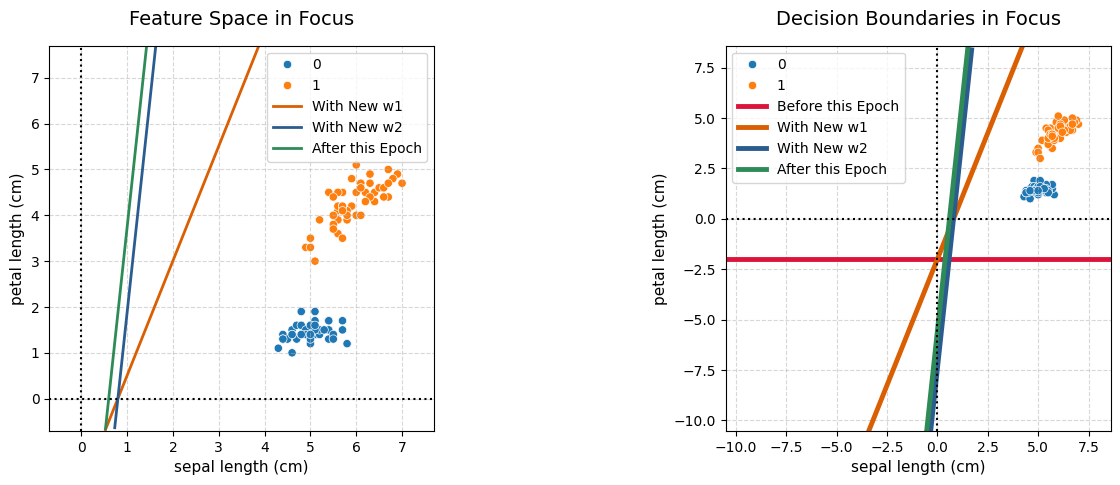



After this Epoch: w = [-2.503  0.269] b = 1.5
Number of Misclassified Point(s): 50



******************************************************************************************************************************************************
******************************************************************************************************************************************************
******************************************************************************************************************************************************





Epoch Number: 2

Before this Epoch:
w = [-2.503  0.269] b = 1.5
Number of Misclassified Point(s): 50





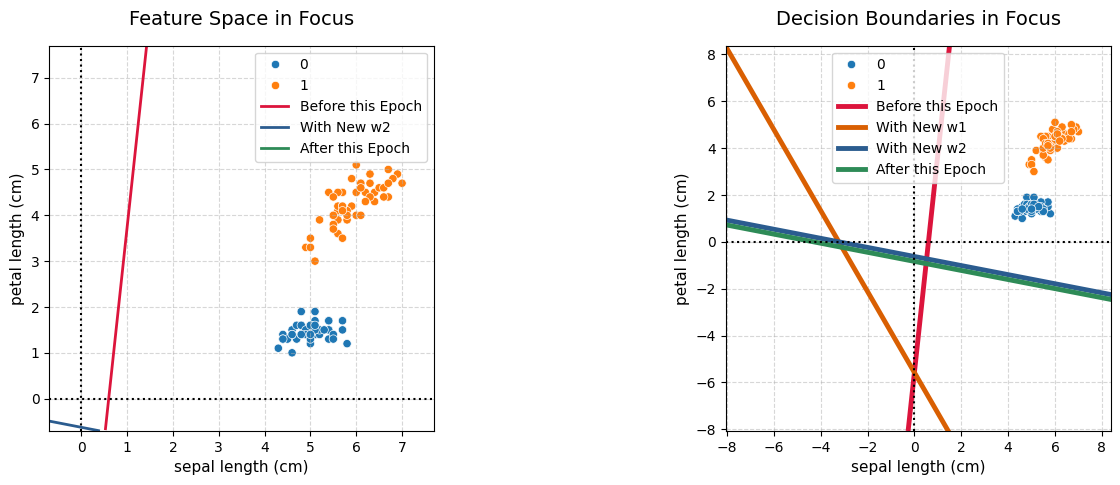



After this Epoch: w = [0.465 2.399] b = 2.0
Number of Misclassified Point(s): 50



******************************************************************************************************************************************************
******************************************************************************************************************************************************
******************************************************************************************************************************************************





Epoch Number: 3

Before this Epoch:
w = [0.465 2.399] b = 2.0
Number of Misclassified Point(s): 50





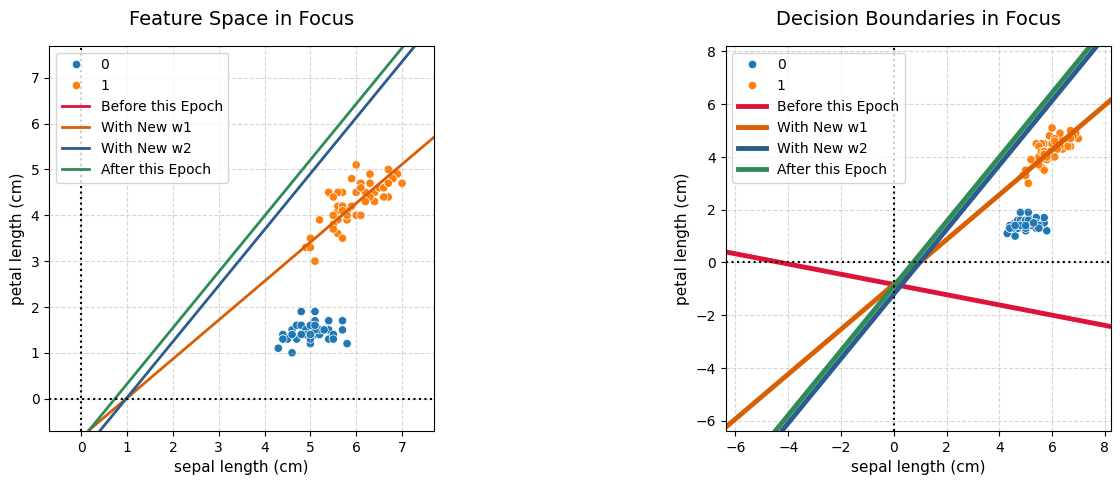



After this Epoch: w = [-2.038  1.668] b = 1.5
Number of Misclassified Point(s): 50



******************************************************************************************************************************************************
******************************************************************************************************************************************************
******************************************************************************************************************************************************





Epoch Number: 4

Before this Epoch:
w = [-2.038  1.668] b = 1.5
Number of Misclassified Point(s): 50





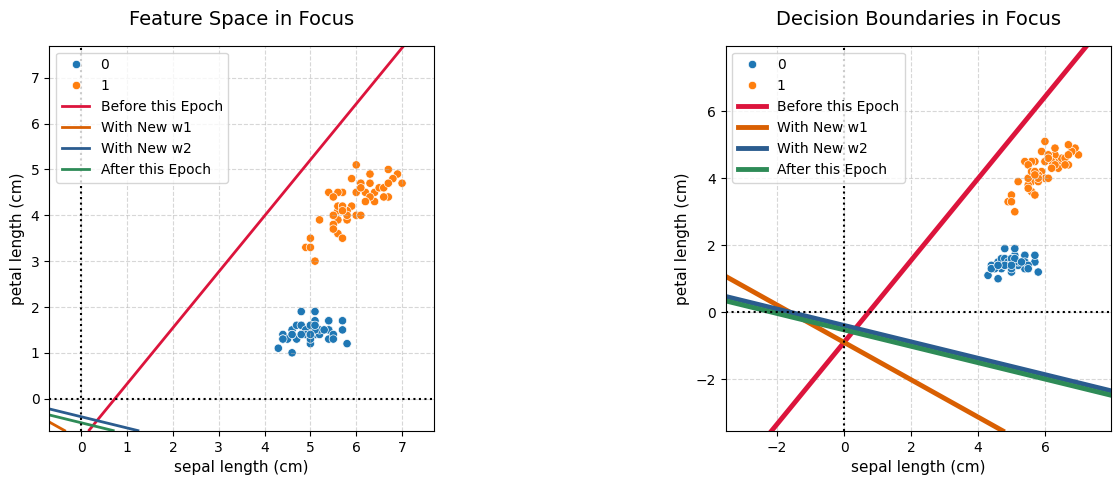



After this Epoch: w = [0.93  3.798] b = 2.0
Number of Misclassified Point(s): 50



******************************************************************************************************************************************************
******************************************************************************************************************************************************
******************************************************************************************************************************************************





Epoch Number: 5

Before this Epoch:
w = [0.93  3.798] b = 2.0
Number of Misclassified Point(s): 50





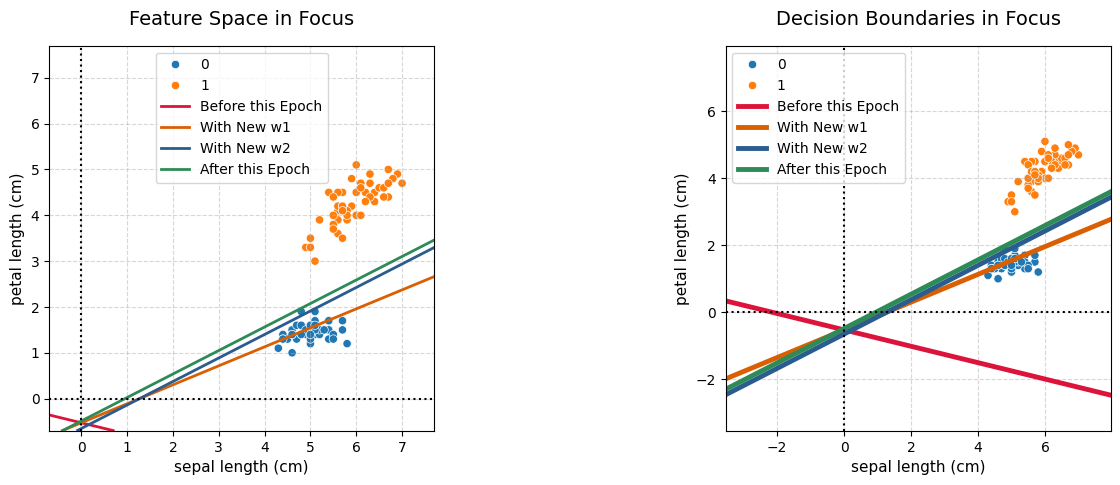



After this Epoch: w = [-1.573  3.067] b = 1.5
Number of Misclassified Point(s): 0



******************************************************************************************************************************************************
******************************************************************************************************************************************************
******************************************************************************************************************************************************







In [127]:
perceptron1 = Perceptron(eta = 0.01)
perceptron1.fit(X=np.array(X), y=y, initial_w = np.array([0, 1]), initial_b = 2)

## What ChatGPT Expected Me to Learn from this Project

Project 3 was your first complete learning algorithm.

The main lessons were:

- Learning is an iterative optimization process.
- The decision boundary moves during training.
- Misclassifications decrease over time on linearly separable data.
- Learning rate affects convergence speed.
- Training is fundamentally different from prediction.

Most importantly, you should now appreciate that learning means adjusting parameters based on errors.